# Used Cars Price Prediction

1. understanding the data,
2. exploratory analysis with plots,
3. preprocessing,
4. baseline models,
5. feature importance and feature selection,
6. hyperparameter tuning with cross-validation,
7. final evaluation and interpretation.

## Dataset

**Used cars price dataset** (Hyundai cars from the UK used car market)

- it is a **regression** problem,
- it contains both numerical and categorical variables,
- it is large enough to show non-trivial modeling effects,
- it is suitable for feature selection, regularization, and cross-validation.

## Part 1. Environment and imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, KFold, RandomizedSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    print("xgboost is not installed")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Part 2. Loading the data

In [6]:
DATA_PATH = Path("hyundi.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.info()
df.head()

(4860, 9)
<class 'pandas.DataFrame'>
RangeIndex: 4860 entries, 0 to 4859
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         4860 non-null   str    
 1   year          4860 non-null   int64  
 2   price         4860 non-null   int64  
 3   transmission  4860 non-null   str    
 4   mileage       4860 non-null   int64  
 5   fuelType      4860 non-null   str    
 6   tax(£)        4860 non-null   int64  
 7   mpg           4860 non-null   float64
 8   engineSize    4860 non-null   float64
dtypes: float64(2), int64(4), str(3)
memory usage: 341.8 KB


,model,year,price,transmission,mileage,fuelType,tax(£),mpg,engineSize
0,I20,2017,7999,Manual,17307,Petrol,145,58.900,1.200
1,Tucson,2016,14499,Automatic,25233,Diesel,235,43.500,2.000
2,Tucson,2016,11399,Manual,37877,Diesel,30,61.700,1.700
3,I10,2016,6499,Manual,23789,Petrol,20,60.100,1.000
4,IX35,2015,10199,Manual,33177,Diesel,160,51.400,2.000


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model,4860,16,Tucson,1300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,"4,860.000",NaN,NaN,NaN,"2,017.108",1.920,"2,000.000","2,016.000","2,017.000","2,019.000","2,020.000"
price,"4,860.000",NaN,NaN,NaN,"12,750.131","5,992.922","1,200.000","8,000.000","11,990.000","15,733.750","92,000.000"
transmission,4860,4,Manual,3611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,"4,860.000",NaN,NaN,NaN,"21,486.050","17,710.197",1.000,"8,339.250","17,462.000","30,967.000","138,000.000"
fuelType,4860,4,Petrol,2902,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax(£),"4,860.000",NaN,NaN,NaN,121.147,58.003,0.000,125.000,145.000,145.000,555.000
mpg,"4,860.000",NaN,NaN,NaN,53.828,12.736,1.100,44.800,55.400,60.100,256.800
engineSize,"4,860.000",NaN,NaN,NaN,1.458,0.401,0.000,1.200,1.600,1.700,2.900


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

The dataset contains 4860 observations and 9 features describing used Hyundai cars.

Numerical features:
- year
- price
- mileage
- tax
- mpg
- engineSize

Categorical features:
- model
- transmission
- fuelType

There are no missing values in the dataset, which means there is no need to perform imputation.

The target variable will be: price

This is a regression problem where I try to predict the car price based on technical and usage features.

## Part 3. Exploratory Data Analysis (EDA)

In [ ]:
TARGET = "price"

df.columns = [c.strip() for c in df.columns]

if TARGET not in df.columns:
    raise ValueError(f"Expected target column '{TARGET}' not found. Columns: {list(df.columns)}")

df["car_age"] = df["year"].max() - df["year"] if "year" in df.columns else np.nan

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['year', 'price', 'mileage', 'tax(£)', 'mpg', 'engineSize', 'car_age']
Categorical columns: ['model', 'transmission', 'fuelType']


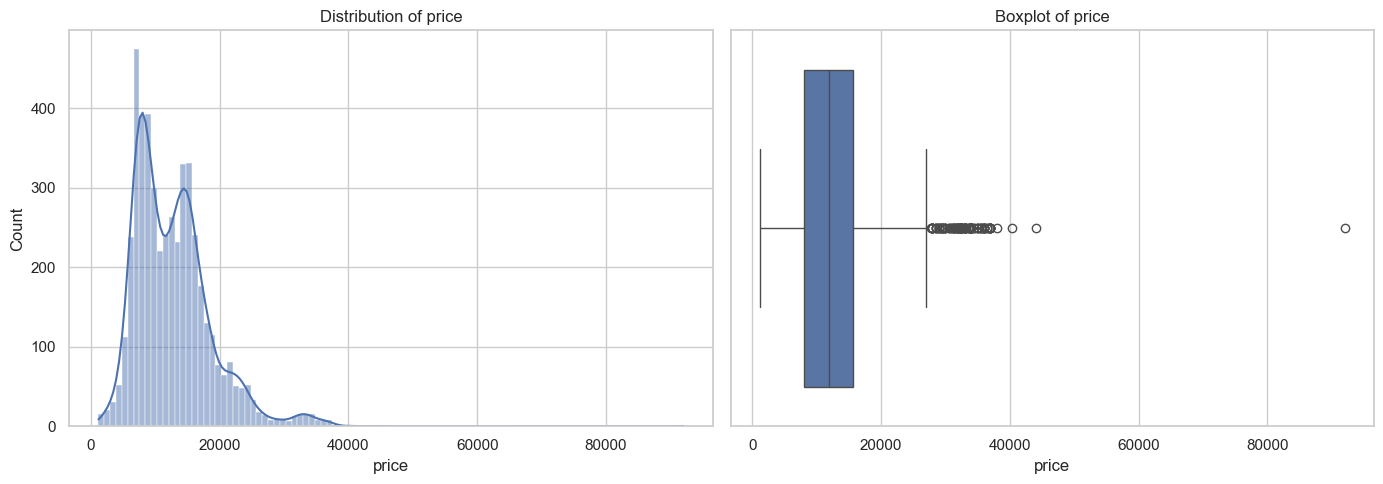

count    4,860.000
mean    12,750.131
std      5,992.922
min      1,200.000
25%      8,000.000
50%     11,990.000
75%     15,733.750
max     92,000.000
Name: price, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[TARGET], kde=True, ax=axes[0])
axes[0].set_title("Distribution of price")

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot of price")

plt.tight_layout()
plt.show()

print(df[TARGET].describe())

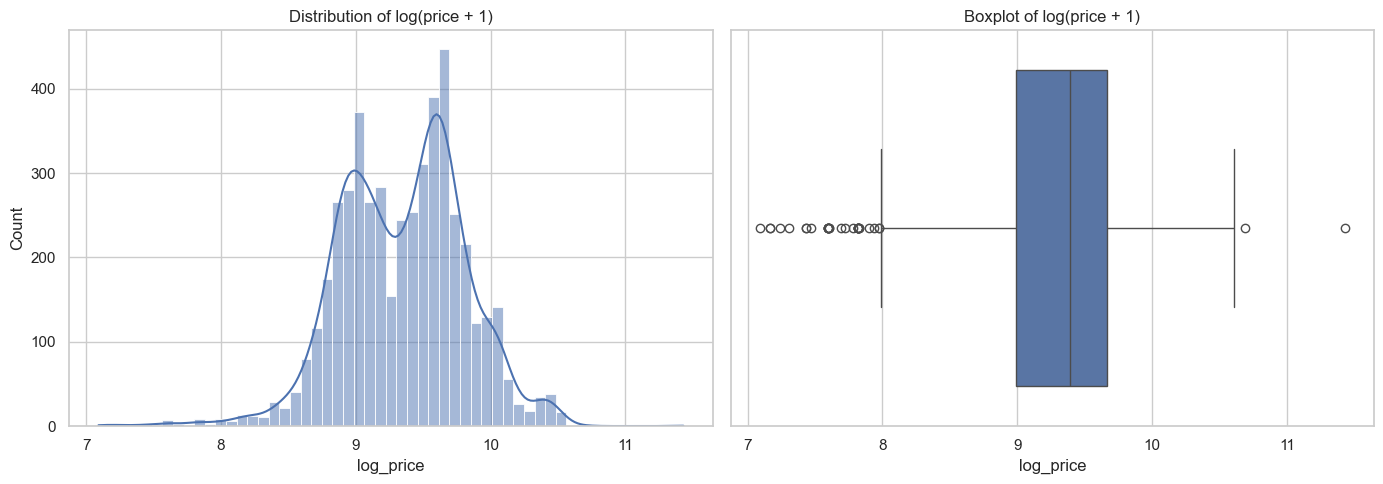

In [ ]:
df["log_price"] = np.log1p(df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["log_price"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of log(price + 1)")

sns.boxplot(x=df["log_price"], ax=axes[1])
axes[1].set_title("Boxplot of log(price + 1)")
plt.tight_layout()
plt.show()

I started by analysing the distribution of the target variable `price`.  
The histogram shows that the distribution is right-skewed, with most cars priced between about 7000 and 20000, and a few very expensive outliers.  
Because of this skewness, I also applied a logarithmic transformation to the price variable, which makes the distribution more symmetric and easier for regression models to learn, so I will consider using it during modelling.

### Numerical feature distributions

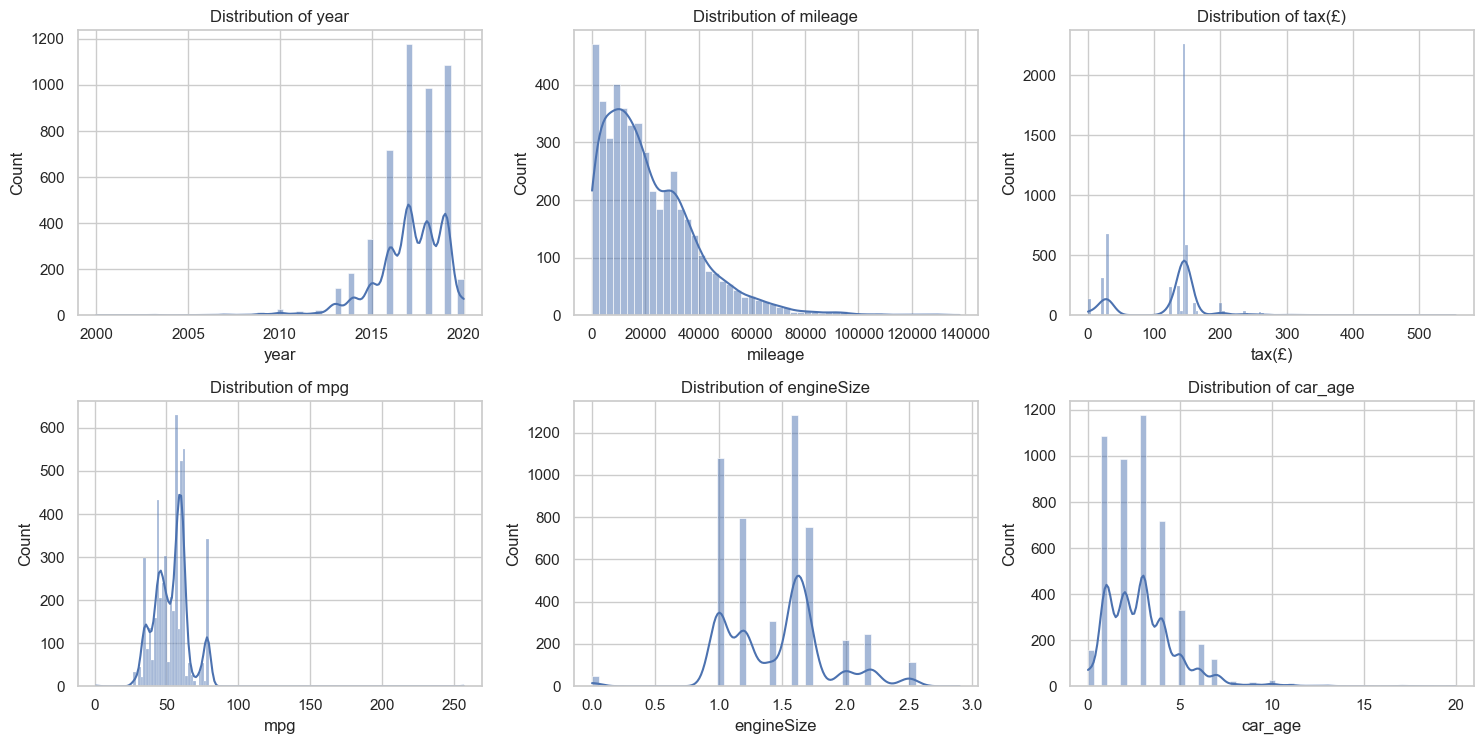

In [16]:
eda_numeric = [c for c in numeric_cols if c not in [TARGET]]
n = len(eda_numeric)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, eda_numeric):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Categorical feature counts

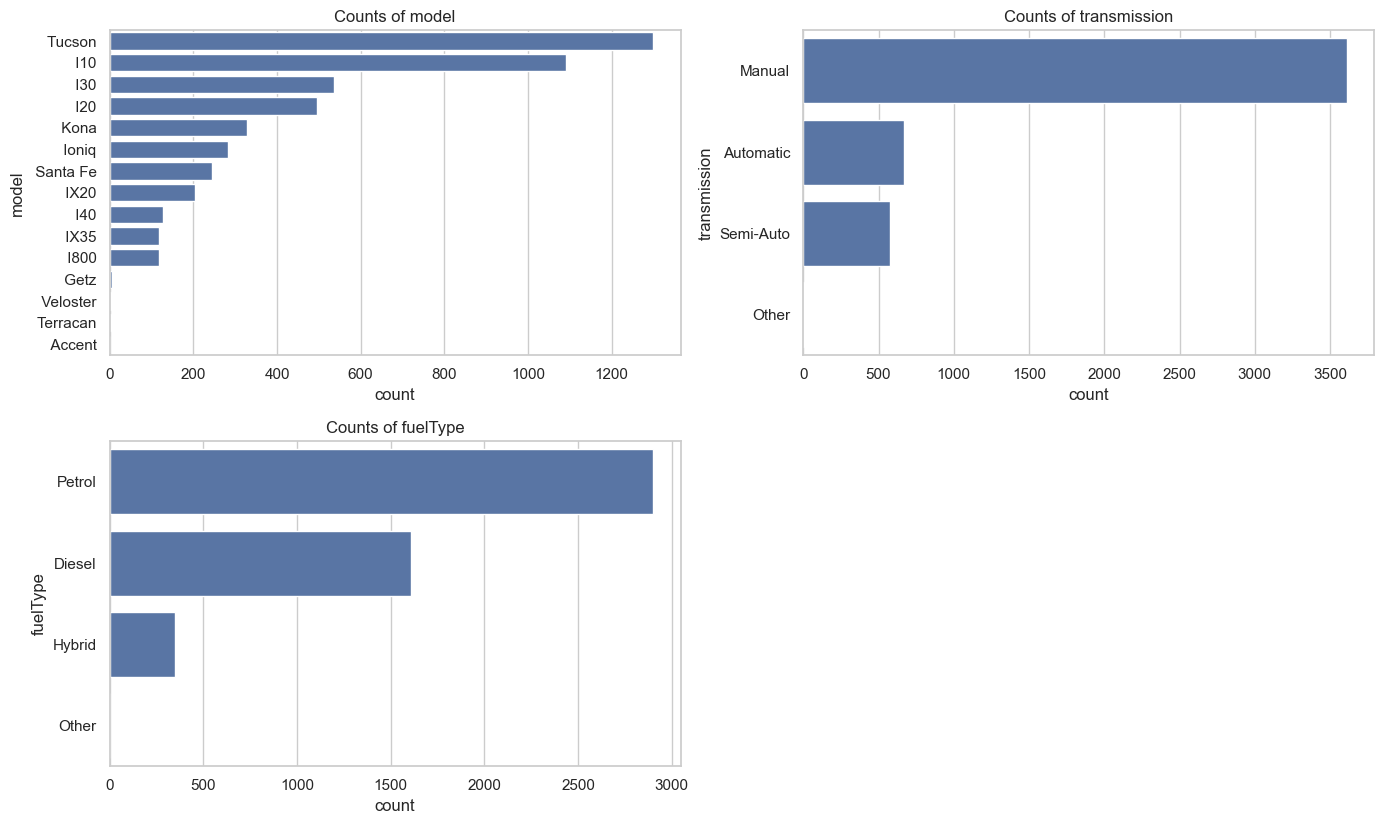

In [ ]:
eda_categorical = [c for c in categorical_cols if c not in [TARGET]]

if len(eda_categorical) > 0:
    n = len(eda_categorical)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, eda_categorical):
        order = df[col].value_counts().index[:15]
        sns.countplot(data=df, y=col, order=order, ax=ax)
        ax.set_title(f"Counts of {col}")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Price vs selected features

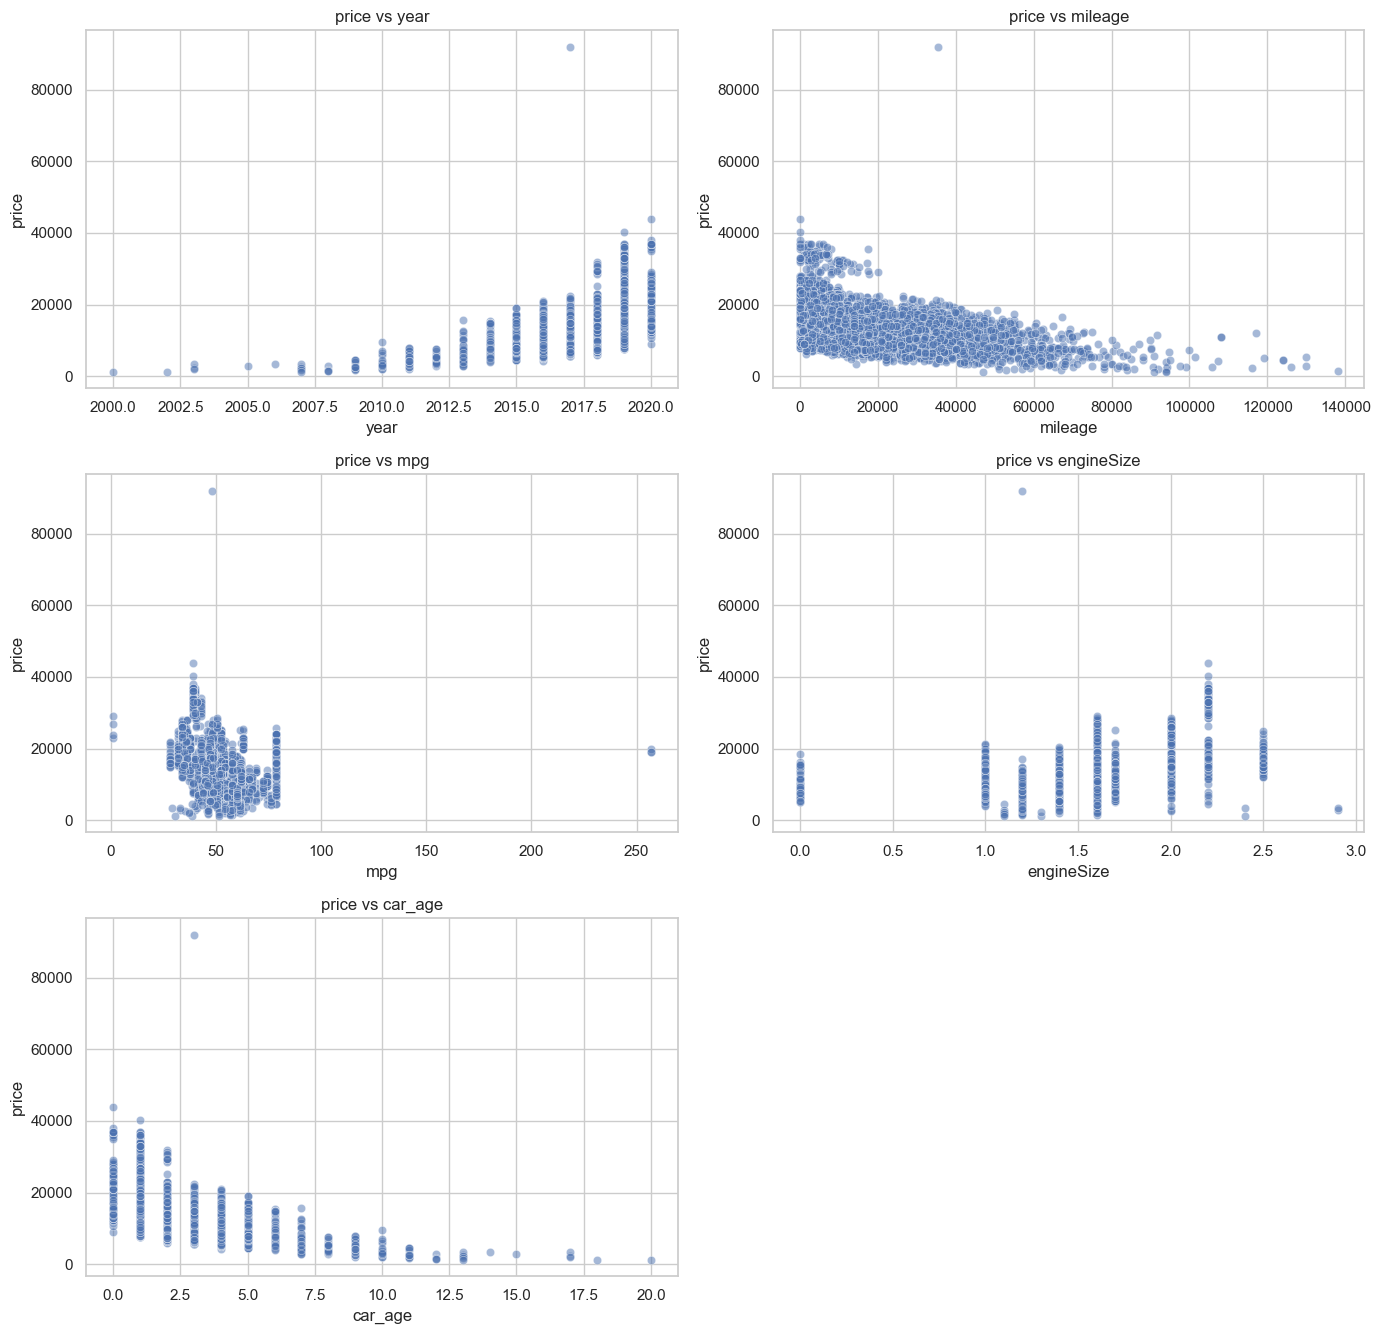

In [ ]:
scatter_candidates = [c for c in ["year", "mileage", "mpg", "engineSize", "tax", "car_age"] if c in df.columns]

n = len(scatter_candidates)
if n > 0:
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, scatter_candidates):
        sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.5, ax=ax)
        ax.set_title(f"{TARGET} vs {col}")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

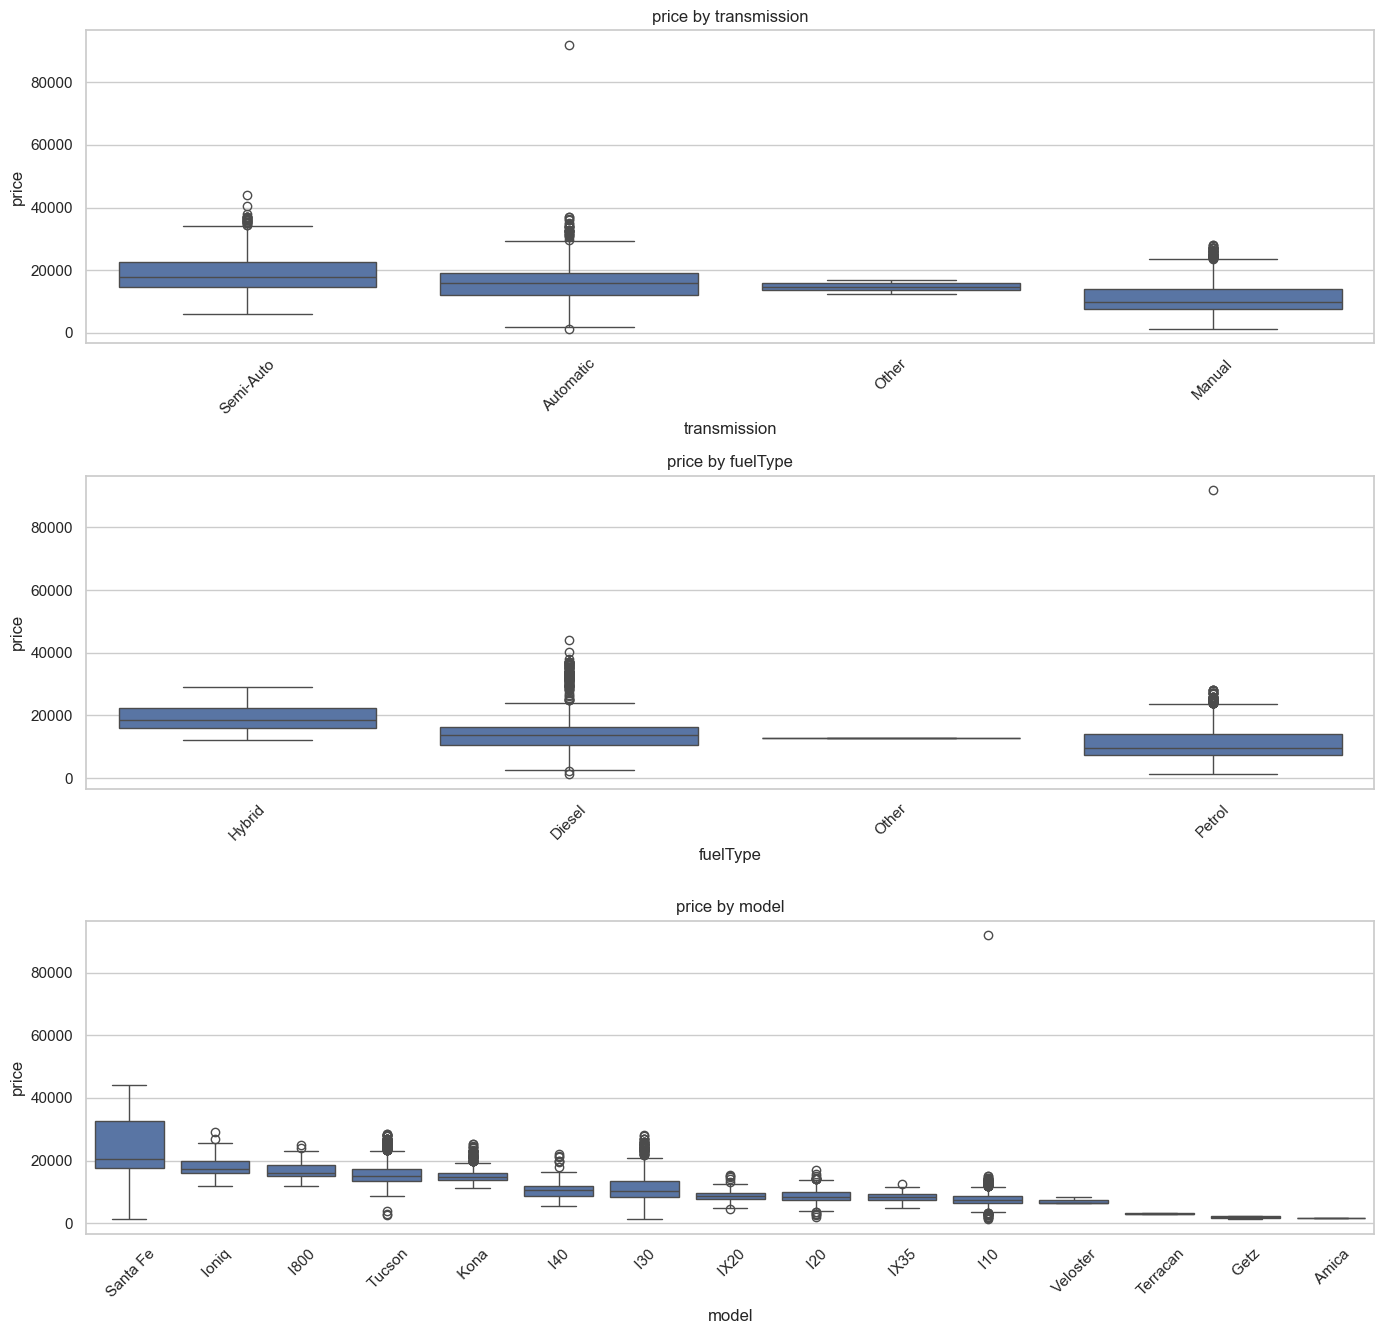

In [ ]:
boxplot_candidates = [c for c in ["transmission", "fuelType", "model"] if c in df.columns]

n = len(boxplot_candidates)
if n > 0:
    ncols = 1
    nrows = n
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, boxplot_candidates):
        order = df.groupby(col)[TARGET].median().sort_values(ascending=False).index[:15]
        sns.boxplot(data=df[df[col].isin(order)], x=col, y=TARGET, order=order, ax=ax)
        ax.set_title(f"{TARGET} by {col}")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### Correlation matrix

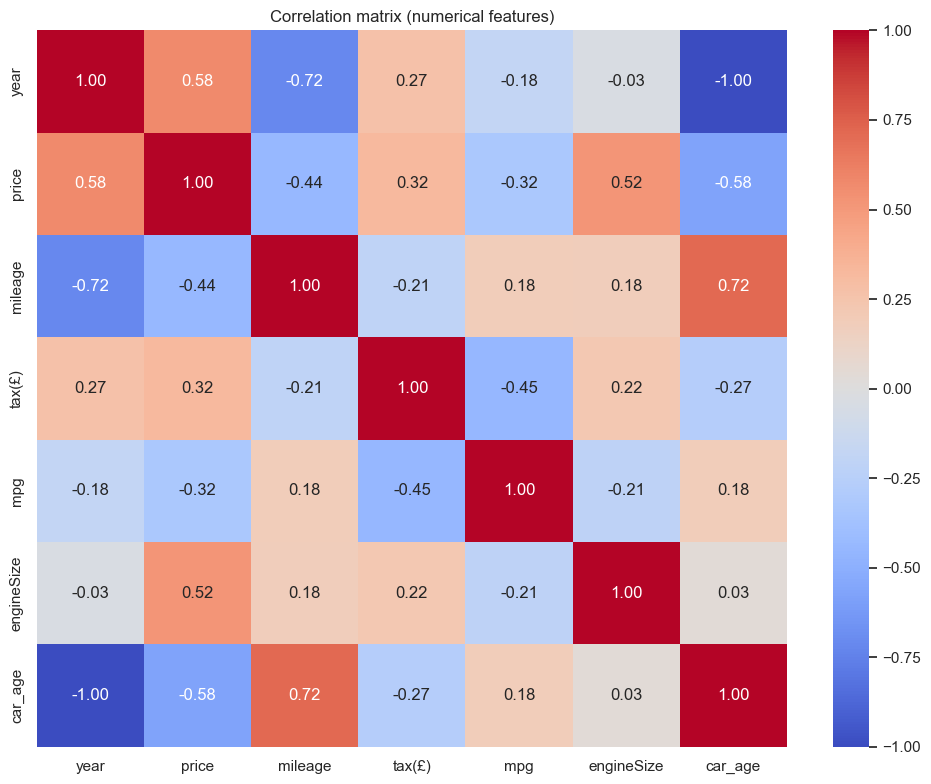

price         1.000
year          0.576
engineSize    0.522
tax(£)        0.321
mpg          -0.320
mileage      -0.444
car_age      -0.576
Name: price, dtype: float64

In [ ]:
corr_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["log_price"]]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numerical features)")
plt.tight_layout()
plt.show()

corr[TARGET].sort_values(ascending=False)

### Conclusions from exploratory analysis

After performing exploratory data analysis, I can see that several features have a strong relationship with the target variable `price`.

From the scatter plots I observe that:

- Newer cars tend to have higher prices
- Cars with higher mileage usually have lower prices
- Larger engine size is often associated with higher price

From the categorical plots:

- Hybrid cars tend to be more expensive than petrol and diesel cars
- Automatic and semi-automatic transmissions are usually more expensive than manual ones

The correlation matrix confirms that the most important numerical variables are likely:

- year
- mileage
- engineSize
- car_age
- mpg

At this stage I keep all features, but later I will use feature importance and model performance to select the most relevant ones and remove less useful variables.

## Part 4. Train-test split and preprocessing

### Modeling strategy
I will predict **log-transformed price** instead of raw price, because the target is right-skewed.  

In the following experiments I will start with the log-transformed target, because it often improves regression performance.  
Later I will compare results obtained using the original price and decide which approach works better.

In [22]:
target_col = "log_price"

feature_cols = [c for c in df.columns if c not in ["price", "log_price"]]
X = df[feature_cols].copy()
y = df[target_col].copy()

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, num_features),
        ("cat", categorical_preprocessor, cat_features),
    ]
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Numeric features:", num_features)
print("Categorical features:", cat_features)

X_train shape: (3888, 9)
X_test shape: (972, 9)
Numeric features: ['year', 'mileage', 'tax(£)', 'mpg', 'engineSize', 'car_age']
Categorical features: ['model', 'transmission', 'fuelType']


I split the dataset into training and test sets using 80% of the data for training and 20% for testing.

The target variable is the logarithm of price.

Features were divided into numerical and categorical.

For preprocessing I used a pipeline:

- numerical features → median imputation + standard scaling
- categorical features → most frequent imputation + one-hot encoding

This approach allows the same preprocessing to be applied consistently during cross-validation and model training.

## Part 5. Baseline models

I start from several baselines and compare them using **cross-validation** on the training set.  

### Metrics
- R2: how much variance is explained,
- RMSE: average prediction error magnitude (in log-price units here),
- MAE: median-like robust average error.

In [23]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "DecisionTree": DecisionTreeRegressor(random_state=42, max_depth=8),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1, max_depth=None
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "MLP_small": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        alpha=0.0005,
        max_iter=1000,
        random_state=42
    ),
}

if XGB_AVAILABLE:
    baseline_models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

results = []

for name, model in baseline_models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "r2": "r2",
            "rmse": rmse_scorer,
            "mae": "neg_mean_absolute_error"
        },
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        "model": name,
        "cv_r2_mean": np.mean(scores["test_r2"]),
        "cv_r2_std": np.std(scores["test_r2"]),
        "cv_rmse_mean": -np.mean(scores["test_rmse"]),
        "cv_mae_mean": -np.mean(scores["test_mae"]),
    })

results_df = pd.DataFrame(results).sort_values("cv_r2_mean", ascending=False)
results_df

,model,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_mae_mean
8,XGBoost,0.964,0.003,0.087,0.064
4,RandomForest,0.957,0.004,0.096,0.069
5,ExtraTrees,0.956,0.003,0.098,0.070
6,GradientBoosting,0.954,0.003,0.099,0.074
1,Ridge,0.936,0.013,0.116,0.086
2,Lasso,0.936,0.011,0.117,0.087
0,LinearRegression,0.936,0.013,0.116,0.086
3,DecisionTree,0.933,0.003,0.120,0.086
7,MLP_small,0.303,1.250,0.267,0.088


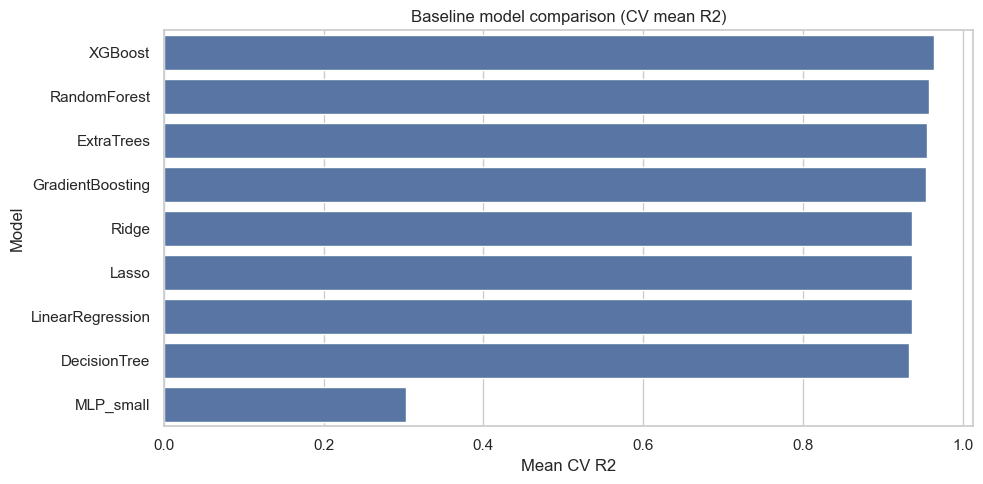

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="cv_r2_mean", y="model")
plt.title("Baseline model comparison (CV mean R2)")
plt.xlabel("Mean CV R2")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

I compared several baseline regression models using cross-validation.

The performance of many models is quite similar, which suggests that the dataset contains strong predictive features.

Tree-based ensemble methods still perform slightly better, which indicates that there are nonlinear relationships between variables.

## Part 6. Feature importance and feature selection

I will identify the most important features and later remove weaker ones.

I will use:
1. Random Forest feature importance,
2. Permutation importance on the validation data.

Because categorical features are one-hot encoded, importance is first computed on the transformed matrix.  
Then I aggregate it back to the feature-name level as much as possible.

In [ ]:
rf_for_importance = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ))
])

rf_for_importance.fit(X_train, y_train)

feature_names = rf_for_importance.named_steps["prep"].get_feature_names_out()
importances = rf_for_importance.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "feature_transformed": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

imp_df.head(20)

,feature_transformed,importance
4,num__engineSize,0.331
0,num__year,0.229
5,num__car_age,0.216
3,num__mpg,0.072
1,num__mileage,0.054
17,cat__model_ Santa Fe,0.037
10,cat__model_ I30,0.016
8,cat__model_ I10,0.009
22,cat__transmission_Manual,0.008
13,cat__model_ IX20,0.007


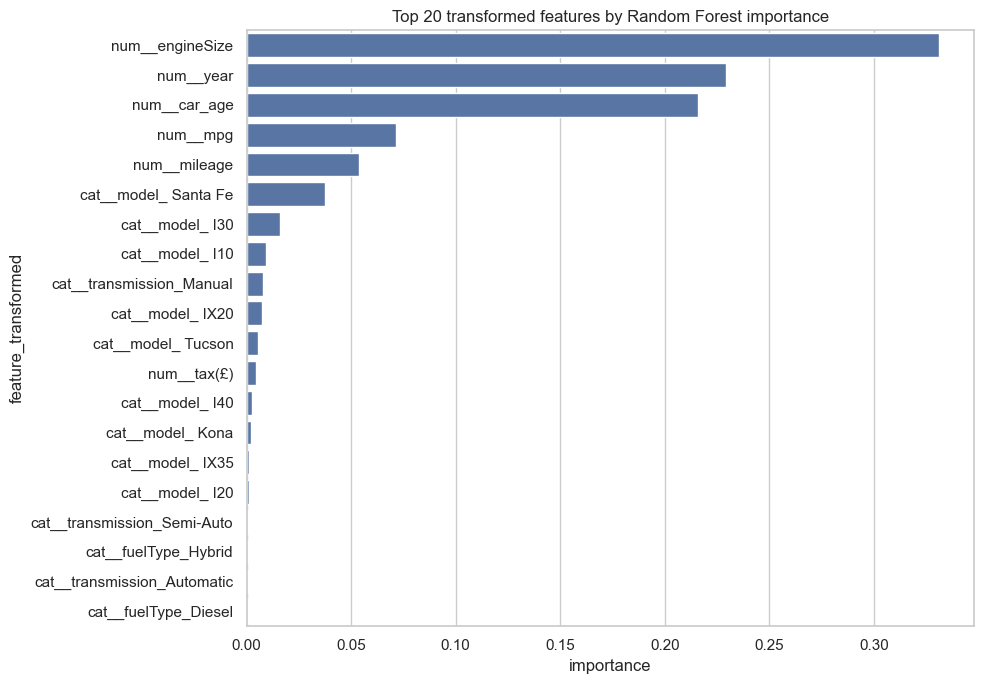

In [26]:
plt.figure(figsize=(10, 7))
sns.barplot(data=imp_df.head(20), x="importance", y="feature_transformed")
plt.title("Top 20 transformed features by Random Forest importance")
plt.tight_layout()
plt.show()

In [28]:
def original_feature_name(transformed_name):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")
    if transformed_name.startswith("cat__"):
        rest = transformed_name.replace("cat__", "")
        for base in cat_features:
            if rest.startswith(base + "_"):
                return base
        return rest
    return transformed_name

agg_imp = (
    imp_df.assign(feature_original=imp_df["feature_transformed"].map(original_feature_name))
          .groupby("feature_original", as_index=False)["importance"]
          .sum()
          .sort_values("importance", ascending=False)
)

agg_imp

,feature_original,importance
1,engineSize,0.331
8,year,0.229
0,car_age,0.216
4,model,0.082
5,mpg,0.072
3,mileage,0.054
7,transmission,0.009
6,tax(£),0.004
2,fuelType,0.002


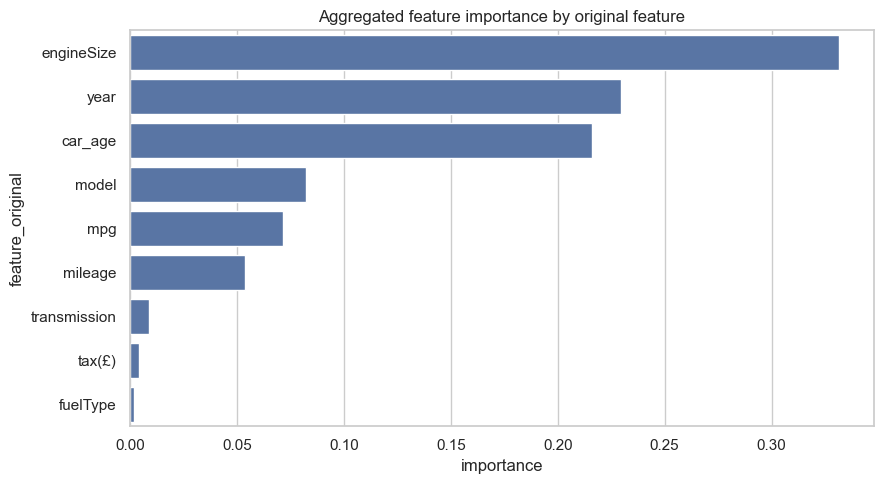

In [29]:
plt.figure(figsize=(9, 5))
sns.barplot(data=agg_imp, x="importance", y="feature_original")
plt.title("Aggregated feature importance by original feature")
plt.tight_layout()
plt.show()

In [30]:
perm = permutation_importance(
    rf_for_importance,
    X_test,
    y_test,
    n_repeats=8,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
7,engineSize,0.486,0.019
0,model,0.156,0.008
1,year,0.123,0.008
6,mpg,0.111,0.007
8,car_age,0.108,0.008
3,mileage,0.069,0.004
2,transmission,0.020,0.002
5,tax(£),0.002,0.000
4,fuelType,0.001,0.000


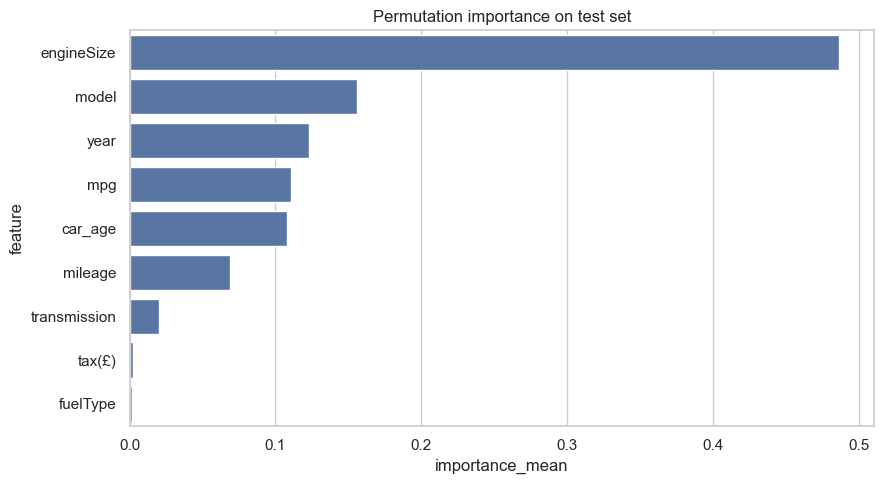

In [31]:
plt.figure(figsize=(9, 5))
sns.barplot(data=perm_df, x="importance_mean", y="feature")
plt.title("Permutation importance on test set")
plt.tight_layout()
plt.show()

The feature importance analysis shows that engine size, year, car age and model are the strongest predictors of car price.

Both Random Forest importance and permutation importance indicate that engineSize is by far the most influential feature. This is expected, because engine size is strongly related to car class and performance.

Year and car_age also have high importance, which confirms that newer cars tend to be more expensive.

Model, mpg and mileage have moderate importance, while transmission, fuel type and tax have very low impact on prediction performance.

Based on these results, weaker features will be removed in the next step to simplify the model.

Year and car_age represent the same information, because car_age is derived from year.  
Since they are highly correlated, only one of them should be kept to avoid redundancy.
I decided to keep car_age because it is easier to interpret than the raw production year.

## Part 7. Controlled experiments with reduced feature sets

I compare:
- all features,
- top 8 features,
- top 6 features,
- top 4 features,
- top 3 features.

The ranking is based on aggregated Random Forest importance.

In [32]:
ranked_features = agg_imp["feature_original"].tolist()

feature_subsets = {
    "all_features": ranked_features,
    "top_8": ranked_features[:8],
    "top_6": ranked_features[:6],
    "top_4": ranked_features[:4],
    "top_3": ranked_features[:3],
}

candidate_model = RandomForestRegressor(
    n_estimators=350,
    random_state=42,
    n_jobs=-1
)

subset_results = []

for subset_name, subset_cols in feature_subsets.items():
    X_sub = X_train[subset_cols].copy()

    sub_num = X_sub.select_dtypes(include=np.number).columns.tolist()
    sub_cat = [c for c in X_sub.columns if c not in sub_num]

    sub_preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), sub_num),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), sub_cat),
        ]
    )

    pipe = Pipeline([
        ("prep", sub_preprocessor),
        ("model", candidate_model)
    ])

    scores = cross_validate(
        pipe,
        X_sub,
        y_train,
        cv=cv,
        scoring={"r2": "r2", "rmse": rmse_scorer},
        n_jobs=-1
    )

    subset_results.append({
        "subset": subset_name,
        "n_features": len(subset_cols),
        "features": ", ".join(subset_cols),
        "cv_r2_mean": np.mean(scores["test_r2"]),
        "cv_rmse_mean": -np.mean(scores["test_rmse"]),
    })

subset_results_df = pd.DataFrame(subset_results).sort_values("cv_r2_mean", ascending=False)
subset_results_df

,subset,n_features,features,cv_r2_mean,cv_rmse_mean
0,all_features,9,"engineSize, year, car_age, model, mpg, mileage...",0.957,0.096
1,top_8,8,"engineSize, year, car_age, model, mpg, mileage...",0.957,0.096
2,top_6,6,"engineSize, year, car_age, model, mpg, mileage",0.956,0.097
3,top_4,4,"engineSize, year, car_age, model",0.930,0.123
4,top_3,3,"engineSize, year, car_age",0.859,0.174


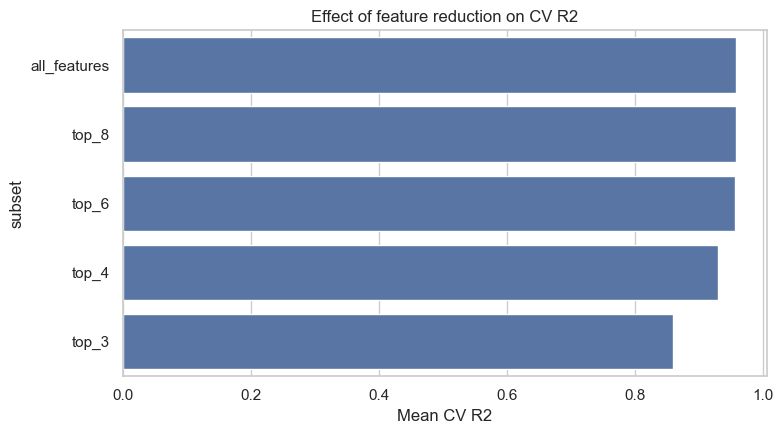

In [33]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=subset_results_df, x="cv_r2_mean", y="subset")
plt.title("Effect of feature reduction on CV R2")
plt.xlabel("Mean CV R2")
plt.tight_layout()
plt.show()

I performed controlled experiments using reduced feature sets based on the Random Forest importance ranking.

The results show that removing the weakest features does not significantly decrease performance.  
The model using the top 8 and top 6 features achieves almost the same R2 as the model using all features.

However, when the number of features is reduced to 4 or 3, the performance drops noticeably, which means that some important information is lost.

This suggests that the most relevant features for price prediction are:
engineSize, year, car_age, model, mpg and mileage.

Using this reduced feature set allows the model to stay accurate while being simpler and easier to interpret.

## Part 8. Hyperparameter tuning

I now tune the strongest families of models, guided by previous results:
- Random Forest,
- XGBoost,
- ExtraTrees
- GradientBoosting.

In [ ]:
best_subset_name = "top_6"
best_subset_cols = feature_subsets[best_subset_name]

# redundant feature
best_subset_cols = [c for c in best_subset_cols if c != "year"]

print("Best subset chosen for tuning (but without redundant feature):", best_subset_name)
print(best_subset_cols)

X_train_best = X_train[best_subset_cols].copy()
X_test_best = X_test[best_subset_cols].copy()

best_num = X_train_best.select_dtypes(include=np.number).columns.tolist()
best_cat = [c for c in X_train_best.columns if c not in best_num]

best_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), best_num),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), best_cat),
    ]
)

Best subset chosen for tuning (but without redundant feature): top_6
['engineSize', 'car_age', 'model', 'mpg', 'mileage']


In [39]:
rf_pipe = Pipeline([
    ("prep", best_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 8, 12, 16, 22],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": [1.0, "sqrt", 0.7],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_best, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best RF CV R2:", rf_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best RF params: {'model__n_estimators': 700, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 22}
Best RF CV R2: 0.960327782115246


In [40]:
if XGB_AVAILABLE:
    xgb_pipe = Pipeline([
        ("prep", best_preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])

    xgb_param_dist = {
        "model__n_estimators": [200, 400, 700],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
        "model__reg_alpha": [0.0, 0.01, 0.1, 0.5],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    }

    xgb_search = RandomizedSearchCV(
        estimator=xgb_pipe,
        param_distributions=xgb_param_dist,
        n_iter=20,
        scoring="r2",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    xgb_search.fit(X_train_best, y_train)

    print("Best XGB params:", xgb_search.best_params_)
    print("Best XGB CV R2:", xgb_search.best_score_)
else:
    xgb_search = None

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'model__subsample': 0.7, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 700, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
Best XGB CV R2: 0.965147194790305


In [41]:
gb_pipe = Pipeline([
    ("prep", best_preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.7, 0.85, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_param_dist,
    n_iter=20,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train_best, y_train)

print("Best GB params:", gb_search.best_params_)
print("Best GB CV R2:", gb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best GB params: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 5, 'model__learning_rate': 0.08}
Best GB CV R2: 0.9619320795384096


I tuned the best performing models using the reduced feature set.

The results show that XGBoost achieved the highest cross-validated R2, followed by Gradient Boosting and Random Forest.

All tuned models performed slightly better than the baseline, which confirms that hyperparameter optimization and feature selection improved the model.

Because XGBoost achieved the best validation performance, it will be used as the final model.

## Part 9. Final comparison of tuned models

In [42]:
final_candidates = {
    "Tuned_RandomForest": rf_search.best_estimator_,
    "Tuned_GradientBoosting": gb_search.best_estimator_,
}

if XGB_AVAILABLE and xgb_search is not None:
    final_candidates["Tuned_XGBoost"] = xgb_search.best_estimator_

final_rows = []

for name, est in final_candidates.items():
    est.fit(X_train_best, y_train)
    pred = est.predict(X_test_best)

    final_rows.append({
        "model": name,
        "test_r2_log": r2_score(y_test, pred),
        "test_rmse_log": rmse(y_test, pred),
        "test_mae_log": mean_absolute_error(y_test, pred)
    })

final_results_df = pd.DataFrame(final_rows).sort_values("test_r2_log", ascending=False)
final_results_df

,model,test_r2_log,test_rmse_log,test_mae_log
2,Tuned_XGBoost,0.939,0.112,0.063
1,Tuned_GradientBoosting,0.936,0.115,0.066
0,Tuned_RandomForest,0.934,0.116,0.067


In [47]:
best_model_name = final_results_df.iloc[0]["model"]
best_model = final_candidates[best_model_name]

best_model.fit(X_train_best, y_train)
y_pred_log = best_model.predict(X_test_best)

# Convert back to original price scale
y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

mape = np.mean(
    np.abs((y_test_price - y_pred_price) / np.maximum(y_test_price, 1))
) * 100

final_original_scale = {
    "best_model": best_model_name,
    "test_r2_price_scale": r2_score(y_test_price, y_pred_price),
    "test_rmse_price_scale": rmse(y_test_price, y_pred_price),
    "test_mae_price_scale": mean_absolute_error(y_test_price, y_pred_price),
    "test_mape_price_scale": mape
}

final_original_scale

{'best_model': 'Tuned_XGBoost',
 'test_r2_price_scale': 0.7833504454964048,
 'test_rmse_price_scale': np.float64(2902.9496571583454),
 'test_mae_price_scale': 839.8273506321536,
 'test_mape_price_scale': np.float64(6.200653624657239)}

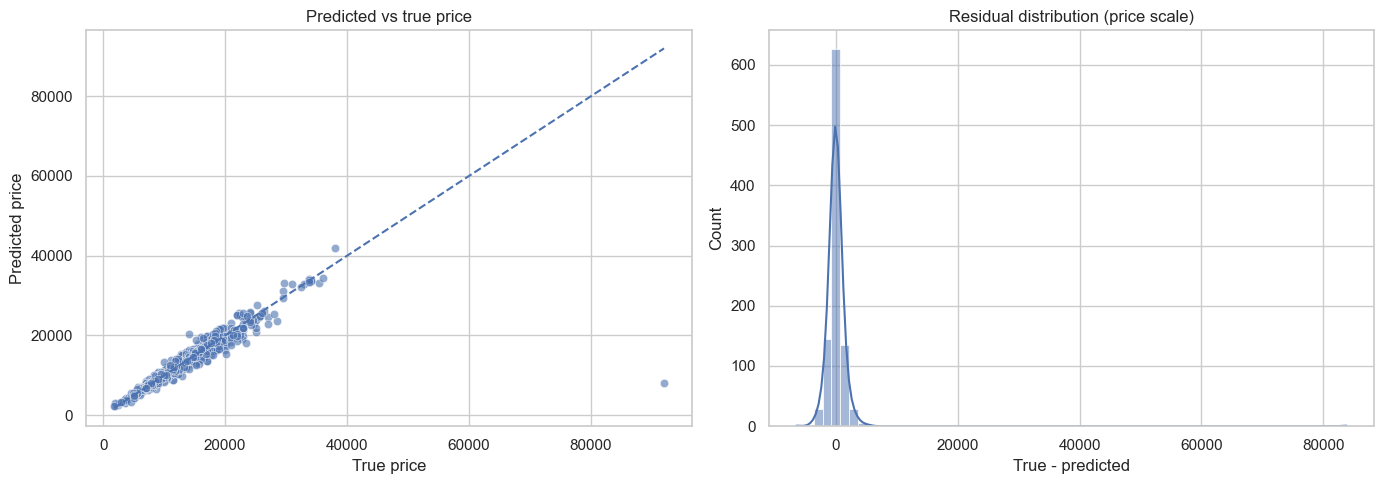

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test_price, y=y_pred_price, alpha=0.6, ax=axes[0])
axes[0].plot(
    [y_test_price.min(), y_test_price.max()],
    [y_test_price.min(), y_test_price.max()],
    linestyle="--"
)
axes[0].set_title("Predicted vs true price")
axes[0].set_xlabel("True price")
axes[0].set_ylabel("Predicted price")

residuals = y_test_price - y_pred_price
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution (price scale)")
axes[1].set_xlabel("True - predicted")

plt.tight_layout()
plt.show()

In [45]:
error_df = pd.DataFrame({
    "true_price": y_test_price,
    "pred_price": y_pred_price,
    "abs_error": np.abs(y_test_price - y_pred_price),
    "pct_error": np.abs(y_test_price - y_pred_price) / np.maximum(y_test_price, 1)
}).sort_values("abs_error", ascending=False)

error_df.head(15)

,true_price,pred_price,abs_error,pct_error
4247,"92,000.000","8,191.043","83,808.957",0.911
1815,"13,990.000","20,458.484","6,468.484",0.462
2819,"23,495.000","18,015.266","5,479.734",0.233
4141,"28,499.000","23,638.355","4,860.645",0.171
2374,"20,113.000","15,270.437","4,842.563",0.241
3811,"25,000.000","20,824.977","4,175.023",0.167
2057,"26,995.000","22,932.539","4,062.461",0.150
3413,"37,995.000","41,878.449","3,883.449",0.102
1730,"15,250.000","18,916.400","3,666.400",0.240
3503,"19,995.000","16,361.640","3,633.360",0.182


## Evaluation metrics and interpretation

I evaluated the models using three standard regression metrics: R2, RMSE and MAE.

R2 measures how much of the variance in the target variable is explained by the model. On the log-transformed scale, the best model 
achieved an R2 of approximately 0.94, which indicates a very strong fit. After converting predictions back to the original price scale, 
the R2 decreases to around 0.78, which is expected due to the nonlinear transformation.

RMSE (Root Mean Squared Error) measures the average magnitude of prediction errors, with higher penalty for large errors. On the original 
price scale, RMSE is around £2900, which suggests that the model occasionally makes larger mistakes, especially for high-value cars.

MAE (Mean Absolute Error) represents the average absolute difference between predicted and actual values. The MAE of approximately £840 indicates 
that, on average, predictions are relatively close to the true prices.

To better understand the error in relative terms, I computed the Mean Absolute Percentage Error (MAPE).
The model's predictions differ from the true values by approximately 6% on average, which indicates that the model is reasonably 
accurate in practical terms.

The difference between RMSE and MAE suggests the presence of outliers, where a small number of predictions have significantly larger errors. 
This is also visible in the residual analysis and error table.

Overall, the model performs well for the majority of observations, but struggles with extreme high-price vehicles.